# Gradient Checking

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import scipy.io

from utils import*

### Load Dataset

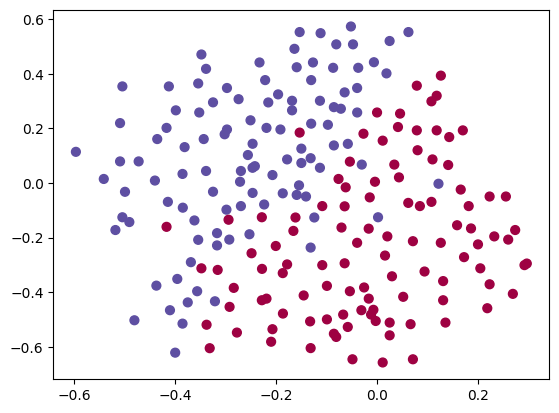

In [2]:
data = scipy.io.loadmat('datasets/data.mat')
train_X = data['X'].T
train_Y = data['y'].T
test_X = data['Xval'].T
test_Y = data['yval'].T

plt.scatter(train_X[0, :], train_X[1, :], c=train_Y, s=40, cmap=plt.cm.Spectral);   

---

### How does Gradient Checking work?
Backpropagation computes the gradients $\frac{\partial J}{\partial \theta}$, where $\theta$ denotes the parameters of the model. $J$ is computed using forward propagation and your loss function.

Because forward propagation is relatively easy to implement, you're confident you got that right, and so you're almost 100% sure that you're computing the cost $J$ correctly. Thus, you can use your code for computing $J$ to verify the code for computing $\frac{\partial J}{\partial \theta}$.

Let's look back at the definition of a derivative (or gradient):$$ \frac{\partial J}{\partial \theta} = \lim_{\varepsilon \to 0} \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2 \varepsilon} \tag{1}$$

If you're not familiar with the "$\displaystyle \lim_{\varepsilon \to 0}$" notation, it's just a way of saying "when $\varepsilon$ is really, really small."

You know the following:

$\frac{\partial J}{\partial \theta}$ is what you want to make sure you're computing correctly.
You can compute $J(\theta + \varepsilon)$ and $J(\theta - \varepsilon)$ (in the case that $\theta$ is a real number), since you're confident your implementation for $J$ is correct.
Let's use equation (1) and a small value for $\varepsilon$ to convince your CEO that your code for computing $\frac{\partial J}{\partial \theta}$ is correct!

---

### N-Dimensional Gradient Checking

The following figure describes the forward and backward propagation of your fraud detection model.

<img src="images/NDgrad_kiank.png" style="width:600px;height:400px;">
<caption><center><font color='purple'><b>Figure 2</b>: Deep neural network. LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID</font></center></caption>

Let's look at your implementations for `forwarxd_propagation` and `backward_propagation`. 

Below is the code provided for `forward_propagation_n`. Note here that `n` in the name implies it is for n-dimensions

In [13]:
def gradient_check_n(parameters, gradients, X, Y, layers_dims, lambd=0, keep_probs=None,epsilon=1e-7, print_msg=False):
    """
    Checks if L_model_backward computes correctly the gradient of the cost output by L_model_forward.
    
    IMPORTANT: dropout must be OFF (keep_probs = all 1.0) for gradient checking to be valid,
    since a fresh random mask is generated on every forward call otherwise.
    
    Arguments:
    parameters -- python dictionary containing "W1", "b1", ..., "WL", "bL"
    gradients -- output of L_model_backward, contains gradients w.r.t. parameters (dW, db keys only)
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector
    layers_dims -- list of layer dimensions, needed to disable dropout during the check
    lambd -- regularization hyperparameter (if you're checking a regularized model)
    epsilon -- tiny shift used for numerical approximation
    
    Returns:
    difference -- relative difference between analytical and numerical gradients
    """
    
    L = len(layers_dims) - 1
    
    
    parameters_values, keys = dictionary_to_vector(parameters)
    grad = gradients_to_vector(gradients, L)
    
    num_parameters = parameters_values.shape[0]
    J_plus = np.zeros((num_parameters, 1))
    J_minus = np.zeros((num_parameters, 1))
    gradapprox = np.zeros((num_parameters, 1))
    
    for i in range(num_parameters):
        # J_plus[i]
        theta_plus = np.copy(parameters_values)
        theta_plus[i] = theta_plus[i] + epsilon
        AL_plus, _ = L_model_forward(X, vector_to_dictionary(theta_plus, layers_dims), keep_probs)
        if lambd == 0:
            J_plus[i] = compute_cost(AL_plus, Y)
        else:
            J_plus[i] = compute_cost_regularized(AL_plus, Y, vector_to_dictionary(theta_plus, layers_dims), lambd)
        
        # J_minus[i]
        theta_minus = np.copy(parameters_values)
        theta_minus[i] = theta_minus[i] - epsilon
        AL_minus, _ = L_model_forward(X, vector_to_dictionary(theta_minus, layers_dims), keep_probs)
        if lambd == 0:
            J_minus[i] = compute_cost(AL_minus, Y)
        else:
            J_minus[i] = compute_cost_regularized(AL_minus, Y, vector_to_dictionary(theta_minus, layers_dims), lambd)
        
        # gradapprox[i]
        gradapprox[i] = (J_plus[i] - J_minus[i]) / (2 * epsilon)
    
    numerator = np.linalg.norm(grad - gradapprox)
    denominator = np.linalg.norm(gradapprox) + np.linalg.norm(grad)
    difference = numerator / denominator
    
    if print_msg:
        if difference > 2e-7:
            print("\033[93m" + "There is a mistake in the backward propagation! difference = " + str(difference) + "\033[0m")
            
            # DEBUG: show the single worst mismatched parameter
            elementwise_diff = np.abs(grad - gradapprox).flatten()
            worst_idx = np.argmax(elementwise_diff)
            print(f"Largest mismatch at: {keys[worst_idx]} (index {worst_idx}) | "
                  f"analytical={grad[worst_idx][0]:.6f}, numerical={gradapprox[worst_idx][0]:.6f}")
        else:
            print("\033[92m" + "Your backward propagation works perfectly fine! difference = " + str(difference) + "\033[0m")
    return difference

In [14]:
def dictionary_to_vector(parameters):
    """Rolls parameters dict into a single flat vector. Also returns key order for later un-rolling."""
    keys = []
    count = 0
    L = len(parameters) // 2
    for l in range(1, L + 1):
        for key in ["W" + str(l), "b" + str(l)]:
            new_vector = np.reshape(parameters[key], (-1, 1))
            keys += [key] * new_vector.shape[0]
            theta = new_vector if count == 0 else np.concatenate((theta, new_vector), axis=0)
            count += 1
    return theta, keys

def vector_to_dictionary(theta, layers_dims):
    """Un-rolls a flat vector back into a parameters dictionary, using layers_dims for shapes."""
    parameters = {}
    L = len(layers_dims) - 1
    idx = 0
    for l in range(1, L + 1):
        w_size = layers_dims[l] * layers_dims[l-1]
        parameters["W" + str(l)] = theta[idx : idx + w_size].reshape((layers_dims[l], layers_dims[l-1]))
        idx += w_size
        
        b_size = layers_dims[l]
        parameters["b" + str(l)] = theta[idx : idx + b_size].reshape((layers_dims[l], 1))
        idx += b_size
    return parameters

def gradients_to_vector(gradients, L):
    """Rolls dW1, db1, ..., dWL, dbL from gradients dict into a single flat vector, in the SAME order as dictionary_to_vector."""
    count = 0
    for l in range(1, L + 1):
        for key in ["dW" + str(l), "db" + str(l)]:
            new_vector = np.reshape(gradients[key], (-1, 1))
            dtheta = new_vector if count == 0 else np.concatenate((dtheta, new_vector), axis=0)
            count += 1
    return dtheta

In [18]:
layers_dims = [train_X.shape[0], 20, 3, 1]
parameters = initialize_parameters(layers_dims)

AL, caches = L_model_forward(train_X, parameters, keep_probs=[1.0, 1.0])  # dropout off
grads = L_model_backward(AL, train_Y, caches, lambd=0)

#grads['dW1'] =grads['dW1']*0 

difference = gradient_check_n(parameters, grads, train_X, train_Y, layers_dims, lambd=0,keep_probs=[1.0, 1.0], print_msg=True)

Your backward propagation works perfectly fine! difference = 1.8357681166827522e-08
